## **Logistic Regression**

**The Scenario -** The Digital Bouncer

- Imagine you are a security engineer at a high-tech student portal. You need to build an automated "Bouncer" system that predicts whether a student will pass an exam based on their attendance percentage.

- **The Decision:** The system doesn't care about the exact score; it only needs to answer: "Will they pass? Yes (1) or No (0)?"


- **The Constraint:** This is a high-stakes gatekeeper. It must be more accurate than a simple guess.

**Raw Labeled Dataset (Student Pass Prediction)**

 - This is labeled data.
    - The goal is to predict a Category (Classification), not a continuous number.

| Attendance (%) | Passed (1 = Yes, 0 = No) |
| -------------- | ------------------------ |
| 40             | 0                        |
| 55             | 0                        |
| 70             | 1                        |
| 85             | 1                        |
| 95             | 1                        |


**Input features (X):** __________________________

**Target variable (y):** __________________________

**Why is this a Classification problem rather than Regression?**

---------------------------------------------------------------------
---------------------------------------------------------------------

**What Is Logistic Regression?**

- Don’t let the name fool you! Even though it has "Regression" in the name, it is used for Classification.

- **Key Idea:** It predicts the Probability (0% to 100%) that an event belongs to a certain category (e.g., "There is an 85% chance this student passes").

- **The S-Curve:** Unlike Linear Regression (a straight line), Logistic Regression uses a Sigmoid function to create an "S" shaped curve that squashes values between 0 and 1.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Creating the dataset
data = {
    "Attendance_Percent": [40, 55, 70, 85, 95],
    "Passed": [0, 0, 1, 1, 1]
}

df = pd.DataFrame(data)
print("Student Data:")
df

Student Data:


,Attendance_Percent,Passed
0,40,0
1,55,0
2,70,1
3,85,1
4,95,1


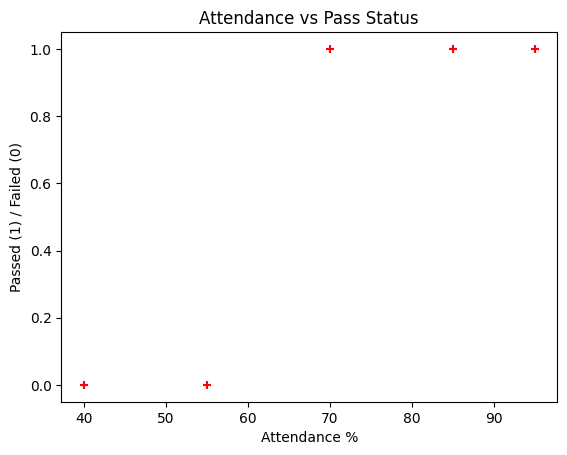

In [4]:
# Visualizing the distribution
plt.scatter(df['Attendance_Percent'], df['Passed'], color='red', marker='+')
plt.xlabel('Attendance %')
plt.ylabel('Passed (1) / Failed (0)')
plt.title('Attendance vs Pass Status')
plt.show()

**Step 2: Preparing Features and Target**

- We separate our "Ingredients" (X) from our "Target" (y).

In [8]:
# X must be a 2D array for Scikit-Learn
X = df[['Attendance_Percent']]
y = df['Passed']

**Step 3: Building the "Bouncer" (Scikit-Learn)**

 - Now we initialize and train the Logistic Regression model.

In [9]:
from sklearn.linear_model import LogisticRegression

# 1. Create the model
model_log = LogisticRegression()

# 2. Teach the model (Fit)
model_log.fit(X,y)

#print("Model Training complete")

LogisticRegression()

In [11]:
print(model_log.coef_)
print(model_log.intercept_)

[[0.46068119]]
[-28.79256948]


**Step 4: Making Predictions**

- Let's ask our "Bouncer": Will a student with 65% attendance pass?

In [14]:
# Define the new student's data
student_data = [[65]]

# Predict Pass (1) or Fail (0)
predicted_result_status = model_log.predict(student_data)
print(predicted_result_status)

# Predict Probability
predict_result_probabilities = model_log.predict_proba(student_data)
print(predict_result_probabilities)

[1]
[[0.24017727 0.75982273]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


**Final Self-Check**
- [x] I understand that Logistic Regression is for Classification, not numerical prediction.

- [x] I can identify the Target (y) as the categorical outcome.

- [x] I understand that the model outputs a Probability between 0 and 1.

- [x] I can use .fit() to train and .predict() to test new data

****
****
****

**Case Study**

**Reducing Subscriber Attrition at TelcoConnect**

**1. Background**
- TelcoConnect, a leading telecommunications provider, is facing increasing competition in a saturated market. The company has observed a trend where long-term subscribers are migrating to competitors, a phenomenon known as "customer churn." To maintain market share and profitability, the executive team has mandated the development of an intelligent retention strategy.

**2. The Challenge**
- The primary goal is to shift from a reactive approach (trying to win back customers after they leave) to a proactive approach (identifying "at-risk" customers before they cancel their service). The company needs to understand the specific triggers—whether it is contract length, billing frustrations, or poor support experiences—that drive a customer to depart.

**Dataset** - https://www.kaggle.com/datasets/sonalshinde123/customer-churn-prediction-dataset